
$ \qquad \displaystyle \dot{x}=h+rx-x^3$

This is one of the standard normal forms connected to Catastrophe theory and especially the **cusp catastrophe**.


**1) Equilibrium points**

Set

$ \qquad \displaystyle \dot{x}=0$

So equilibria satisfy

$ \qquad \displaystyle x^3-rx-h=0$

This cubic determines how many steady states exist.

**2) Why catastrophe theory?**

Catastrophe theory studies how equilibria change suddenly when control parameters vary.

Here:

* (x) → state variable
* (r,h) → control parameters

Small changes in $(r,h)$ can cause sudden jumps in equilibrium.

That sudden jump = catastrophe.

This is the classic Cusp catastrophe.

**3) Potential function**

Since

$ \qquad \displaystyle \dot{x}=-\frac{dV}{dx}$

we can define:

$ \qquad \displaystyle\frac{dV}{dx}=-(h+rx-x^3)$

Integrating:

$ \qquad \displaystyle V(x)=\frac{x^4}{4}-\frac{r}{2}x^2-hx$ 

System rolls toward minima of $V(x)$.

**4) Number of equilibria**

From cubic:

$ \qquad \displaystyle x^3-rx-h=0$

Depending on $(r,h)$:

* one real equilibrium
* three real equilibria

Three equilibria means:

* two stable
* one unstable

This creates hysteresis.

**5) Catastrophe set (bifurcation curve)**

Catastrophe occurs when two equilibria merge:

$ \qquad \displaystyle f(x)=x^3-rx-h$

Require simultaneously:

$ \qquad \displaystyle f(x)=0$

and

$ \qquad \displaystyle f'(x)=0$

From derivative:

$ \qquad \displaystyle 3x^2-r=0$

Thus

$ \qquad \displaystyle r=3x^2$

Substitute into equilibrium equation:

$ \qquad \displaystyle x^3-3x^3-h=0$

$ \qquad \displaystyle -2x^3=h$

$ \qquad \displaystyle h=-2x^3$

Thus catastrophe manifold:

$ \qquad \displaystyle r=3x^2,\quad h=-2x^3$

Eliminate (x):

$ \qquad \displaystyle 27h^2=4r^3$

This is the cusp curve.

**6) Physical meaning**

As parameters slowly vary:

system follows stable equilibrium branch

then suddenly jumps to another branch

Examples:

* stock market crashes
* ecosystem collapse
* buckling
* magnetic hysteresis

**7) Stability**

For

$ \qquad \displaystyle f(x)=h+rx-x^3$

Stability determined by:

$ \qquad \displaystyle f'(x)=r-3x^2$

Stable equilibrium:

$ \qquad \displaystyle f'(x)<0$

Unstable:

$ \qquad \displaystyle f'(x)>0$

**8) Bifurcation diagram**

For fixed (r), varying (h):

S-shaped curve appears.

This is the hallmark of cusp catastrophe.

**Relation to pitchfork bifurcation**

If $h=0$ :

$ \qquad \displaystyle\dot{x}=rx-x^3$

This becomes the normal form of a Pitchfork bifurcation.

Adding $h\neq0$ unfolds the pitchfork into a cusp catastrophe.


In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [2]:
def customize_axes(ax, x_p=0, y_p=0, x_p_direction='bottom', y_p_direction='left'):
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    ax.xaxis.set_ticks_position(x_p_direction)
    ax.spines[x_p_direction].set_position(('data', x_p))

    ax.yaxis.set_ticks_position(y_p_direction)
    ax.spines[y_p_direction].set_position(('data', y_p))

    # Add arrow heads to the axes
    ax.plot(1, 1*x_p, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(1*y_p, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

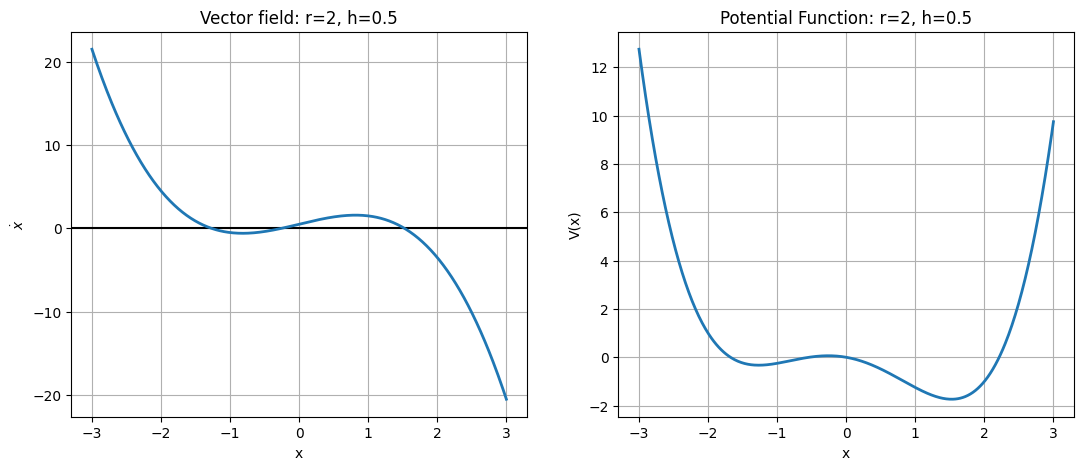

In [3]:
def f(x, r, h):
    return h + r*x - x**3


def potential(x, r, h):
    return x**4/4 - (r/2)*x**2 - h*x


r = 2
h = 0.5

x = np.linspace(-3, 3, 500)
xdot = f(x, r, h)

plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
plt.axhline(0,color='k')
plt.plot(x, xdot, lw=2)
plt.xlabel("x")
plt.ylabel(r"$\dot{x}$")
plt.title(f"Vector field: r={r}, h={h}")
plt.grid()

V = potential(x, r, h)

plt.subplot(1,3,2)
plt.plot(x, V, lw=2)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title(f"Potential Function: r={r}, h={h}")
plt.grid()
plt.show()

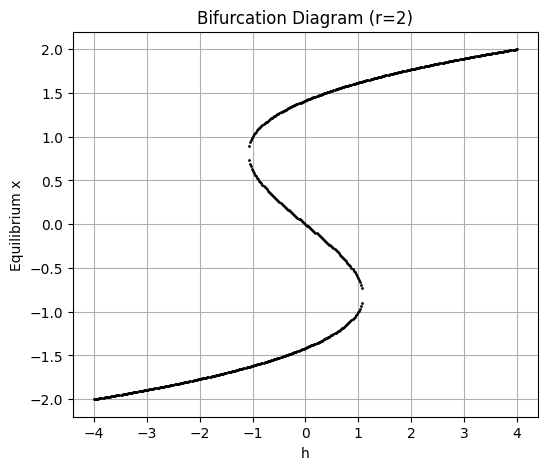

In [4]:
r = 2
h_vals = np.linspace(-4,4,400)

x_all = []
h_all = []

for h in h_vals:
    
    coeff = [1,0,-r,-h]   # x³-rx-h=0
    roots = np.roots(coeff)
    
    real_roots = roots[np.isreal(roots)].real
    
    for root in real_roots:
        x_all.append(root)
        h_all.append(h)

plt.figure(figsize=(6,5))
plt.plot(h_all, x_all, '.k', markersize=2)
plt.xlabel("h")
plt.ylabel("Equilibrium x")
plt.title(f"Bifurcation Diagram (r={r})")
plt.grid()
plt.show()

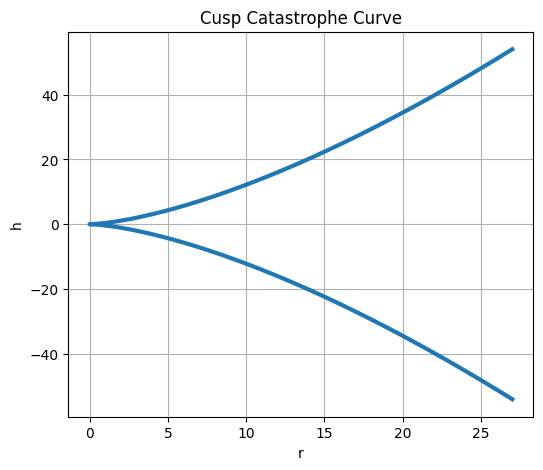

In [5]:
x_cusp = np.linspace(-3,3,400)

r_cusp = 3*x_cusp**2
h_cusp = -2*x_cusp**3

plt.figure(figsize=(6,5))
plt.plot(r_cusp, h_cusp, lw=3)
plt.xlabel("r")
plt.ylabel("h")
plt.title("Cusp Catastrophe Curve")
plt.grid()
plt.show()

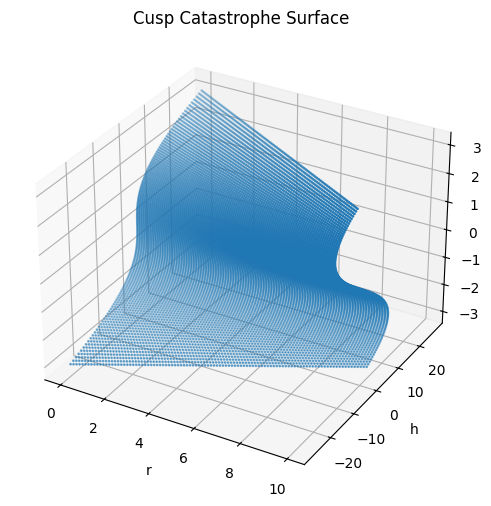

In [6]:
x_surface = np.linspace(-3,3,150)

X = []
R = []
H = []

for x0 in x_surface:
    r_val = np.linspace(0,10,100)
    
    h_val = x0**3 - r_val*x0
    
    X.extend([x0]*len(r_val))
    R.extend(r_val)
    H.extend(h_val)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(R, H, X, s=1)

ax.set_xlabel("r")
ax.set_ylabel("h")
ax.set_zlabel("x")
ax.set_title("Cusp Catastrophe Surface")

plt.show()

**3.6.1**  <span style="color:red">(Warm-up question about imperfect bifurcation)                                                                                              
Does Figure 3.6.3b correspond to $h > 0$ or to $h < 0 ?$ <span>

**Equilibria**                                                                                                                                               
The equilibria satisfy                                                                                                                                       
$\qquad\displaystyle  h+rx-x^3=0,$                                                                                                                              
or $\qquad\displaystyle  x^3-rx-h=0.$                                                                                                                           
Unlike the perfect pitchfork $(h=0)$, this cubic generally cannot be factored.

**Stability**                                                                                                                                                                                                                                                    
Let                                                                                                                                                                                                                                                    
$\qquad\displaystyle f(x)=h+rx-x^3.$                                                                                                                          
Then                                                                                                                                                                                                                                                    
$\qquad\displaystyle f'(x)=r-3x^2.$                                                                                                                          
Hence                                                                                                                                                                                                                                                    
$\qquad\displaystyle  f'(x^*)<0 \Rightarrow$ stable                                                                                                              

$\qquad\displaystyle  f'(x^*)>0 \Rightarrow$ unstable 


$$\begin{array}{|c|c|c|c|}
\hline
\textbf{Case} & \textbf{Equilibrium Equation} & \textbf{Bifurcation \& Fold Behavior} & \textbf{Branch Structure / Stability} \\
\hline
h < 0 & 
\begin{array}{c}
x^3 - rx - h = 0 \\
(h = -|h|)
\end{array} & 
\begin{array}{c}
\text{\textbf{Pitchfork broken downward}} \\
\text{One fold at: } \\
r_{\text{SN}} = 3\left(\dfrac{h^2}{4}\right)^{1/3} \\
x_{\text{SN}} = +\left(\dfrac{|h|}{2}\right)^{1/3}
\end{array} & 
\begin{array}{c}
\text{One stable branch for all } r, \\
\text{one unstable branch, and one} \\
\text{additional stable branch} \\
\text{created at the fold.}
\end{array} \\
\hline
h = 0 & 
x(r - x^2) = 0 & 
\begin{array}{c}
\text{\textbf{Supercritical pitchfork}} \\
\text{Perfect bifurcation} \\
\text{occurs at } r = 0
\end{array} & 
\begin{array}{c}
x^* = 0 \text{ is stable for } r < 0, \\
\text{unstable for } r > 0. \\
x^* = \pm\sqrt{r} \text{ are stable for } r > 0.
\end{array} \\
\hline
h > 0 & 
x^3 - rx - h = 0 & 
\begin{array}{c}
\text{\textbf{Pitchfork broken upward}} \\
\text{One fold at: } \\
r_{\text{SN}} = 3\left(\dfrac{h^2}{4}\right)^{1/3} \\
x_{\text{SN}} = -\left(\dfrac{h}{2}\right)^{1/3}
\end{array} & 
\begin{array}{c}
\text{One stable branch for all } r, \\
\text{one unstable branch, and one} \\
\text{additional stable branch} \\
\text{created at the fold.}
\end{array} \\
\hline
\end{array}$$


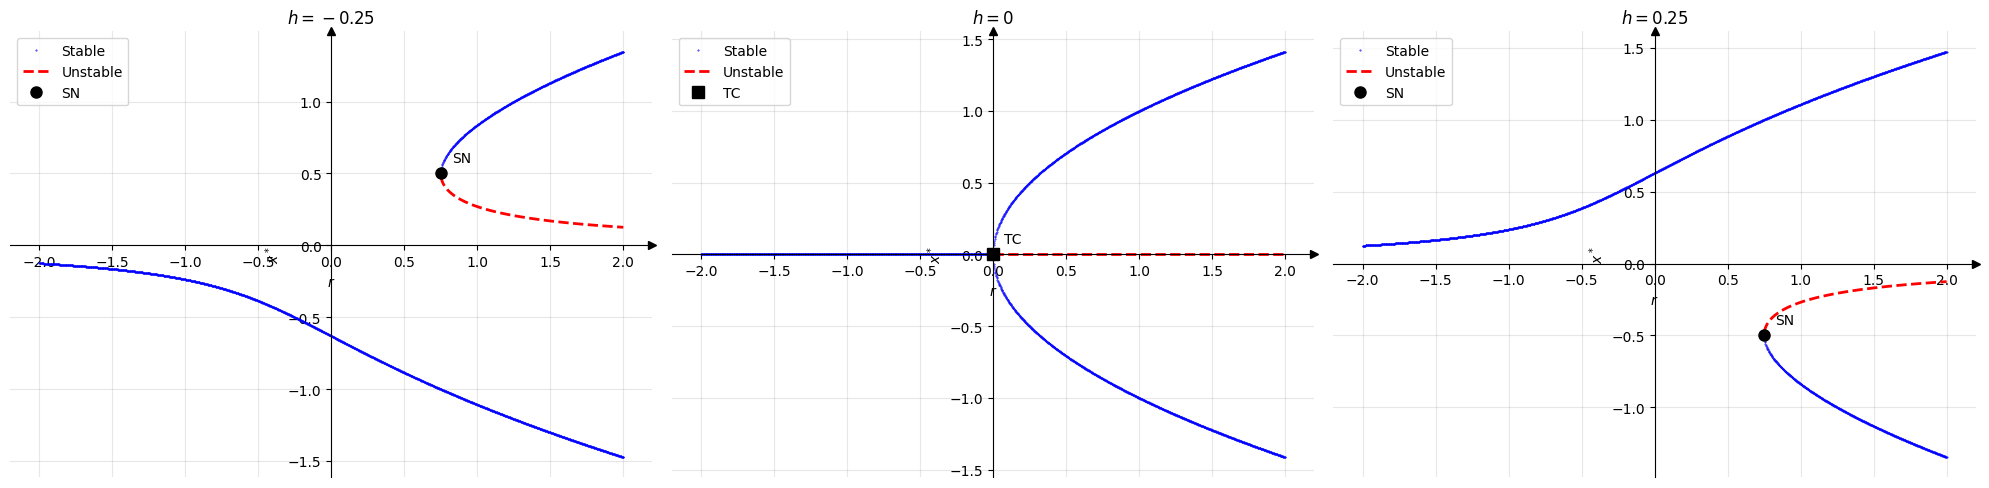

In [7]:
x = np.linspace(-2,2,2000)
rvals = np.linspace(-2,2,1500)
H = [-0.25, 0, 0.25]
fig, ax = plt.subplots(1,3,figsize=(20,5))
for i,h in enumerate(H):
    stable_branches = [[], [], []]
    stable_r        = [[], [], []]
    unstable_branches = [[], [], []]
    unstable_r        = [[], [], []]
    for r in rvals:
        roots = np.roots([1,0,-r,-h])
        real_roots = sorted([z.real for z in roots if abs(z.imag) < 1e-8])
        for j,xr in enumerate(real_roots):
            lam = r - 3*xr**2
            if lam < 0:
                stable_r[j].append(r)
                stable_branches[j].append(xr)
            else:
                unstable_r[j].append(r)
                unstable_branches[j].append(xr)

    ax1 = ax[i]
    for j in range(3):
        ax1.plot(stable_r[j],stable_branches[j],'b.',ms=0.8,label='Stable' if j==0 else "")
        ax1.plot(unstable_r[j],unstable_branches[j],'r--',lw=2,label='Unstable' if j==0 else "")
    if h != 0:
        xsn = -np.cbrt(h/2)
        rsn = 3*xsn**2
        ax1.plot(rsn,xsn,'ko',ms=8,label='SN')
        ax1.annotate('SN',(rsn, xsn),xytext=(8,8),textcoords='offset points')
    else:
        ax1.plot(0,0,'ks',ms=8,label='TC')
        ax1.annotate('TC',(0,0),xytext=(8,8),textcoords='offset points')
    ax1.set_title(fr"$h={h}$")
    ax1.set_xlabel(r"$r$")
    ax1.set_ylabel(r"$x^*$")
    ax1.grid(alpha=0.3)
    ax1.legend()
    customize_axes(ax1)
plt.tight_layout()
plt.show()

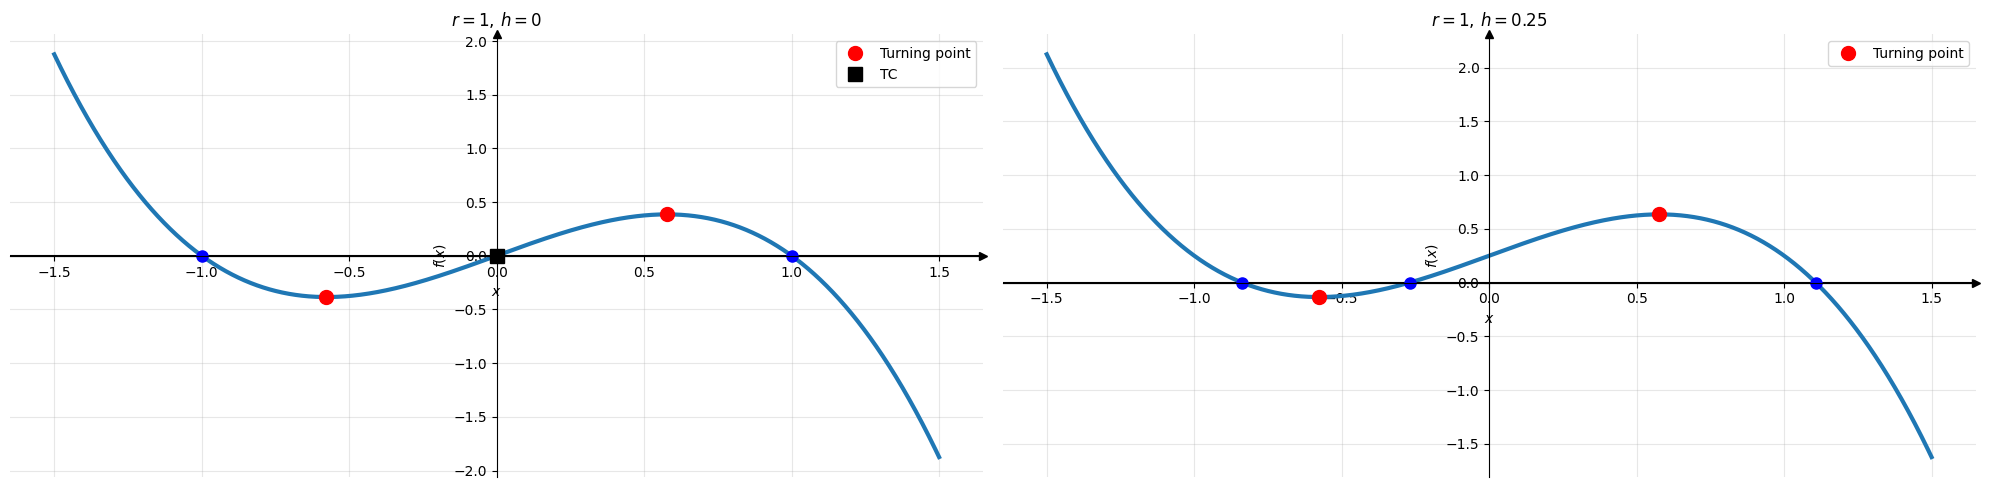

In [8]:
x = np.linspace(-1.5,1.5,2000)
r = 1
H = [0,0.25]

fig,ax = plt.subplots(1,2,figsize=(20,5))
for i,h in enumerate(H):
    f = r*x + h - x**3
    ax[i].plot(x,f,lw=3)
    ax[i].axhline(0,color='k')
    roots = np.roots([1,0,-r,-h])
    for z in roots:
        if abs(z.imag) < 1e-8:
            xr = z.real
            ax[i].plot(xr,0,'bo',ms=8)

    xt1 = -np.sqrt(r/3)
    xt2 =  np.sqrt(r/3)
    yt1 = r*xt1 + h - xt1**3
    yt2 = r*xt2 + h - xt2**3

    ax[i].plot(xt1,yt1,'ro',ms=10,label='Turning point')
    ax[i].plot(xt2,yt2,'ro',ms=10)

    if h == 0:
        ax[i].plot(0,0,'ks',ms=10,label='TC')

    ax[i].set_title(fr"$r={r},\,h={h}$")
    ax[i].set_xlabel(r"$x$")
    ax[i].set_ylabel(r"$f(x)$")
    ax[i].grid(alpha=0.3)
    ax[i].legend()
    customize_axes(ax[i])
plt.tight_layout()
plt.show()

**3.6.2**  <span style="color:red">(Imperfect transcritical bifurcation)                                                                                                              
Consider the system $\displaystyle\dot{x} = h+rx−x^2$ .                                                                                                                          
When $h = 0,$ this system undergoes a transcritical bifurcation at $r = 0$.                                                                                          
Our goal is to see how the bifurcation diagram of $x^{*}$ vs. $r$ is affected by the imperfection parameter $h$.                                                    
a) Plot the bifurcation diagram for $\displaystyle\dot{x} = h+rx−x^2$ , for $h < 0, h = 0,$ and $h > 0$.                                                                                 
b) Sketch the regions in the $( r, h )$ plane that correspond to qualitatively different vector fields,                                                       
$\quad$and identify the bifurcations that occur on the boundaries of those regions.                                                                                           
c) Plot the potential $V ( x )$ corresponding to all the different regions in the $( r, h )$ plane.<span>

**(a) Bifurcation diagram**                                                                                                                                                                                                                                                    
The equilibria satisfy                                                                                                                                                                                                                                                    
$\qquad\displaystyle h + rx - x^2 = 0,$                                                                                                                                                                                                                                                    
or $\quad\displaystyle x^2 - rx - h = 0.$                                                                                                                                                                                                                                                    
Hence                                                                                                                                                                                                                                                    
$\qquad\displaystyle x^*_{\pm} = \frac{r \pm \sqrt{r^2 + 4h}}{2}.$                                                                                                                           
*Stability*                                                                                                                                                                                                                                                    
$\qquad\displaystyle f'(x) = r - 2x.$                                                                                                                                                                                                                                                    
At                                                                                                                                                                
$\qquad\displaystyle x_{\pm} = \frac{r \pm \sqrt{r^2 + 4h}}{2},$                                                                                                                          
we obtain                                                                                                                                                                                                                                                    
$\qquad\displaystyle f'(x_{\pm}) = r - \left(r \pm \sqrt{r^2 + 4h}\right) = \mp\sqrt{r^2 + 4h}.$                                                                                                                          
Therefore                                                                                                                                                                                                                                                    
$x_+ \,\rightarrow$ stable and $x_-\,\rightarrow$  unstable

$$\begin{array}{|c|c|c|c|}
\hline
\textbf{Case} & \textbf{Equilibrium Condition} & \textbf{Bifurcation Behavior} & \textbf{Stability / Branch Properties} \\
\hline
h < 0 & 
\begin{array}{c}
r^2 + 4h \ge 0 \\
\text{Real equilibria exist for } |r| \ge 2\sqrt{-h}
\end{array} & 
\begin{array}{c}
\text{\textbf{Two saddle-node bifurcations}} \\
\text{occur at } r = \pm2\sqrt{-h}
\end{array} & 
\begin{array}{c}
\text{Gap exists for } |r| < 2\sqrt{-h} \\
\text{where no equilibria exist}
\end{array} \\
\hline
h = 0 & 
x = 0, \quad x = r & 
\begin{array}{c}
\text{\textbf{Transcritical bifurcation}} \\
\text{occurs at } r = 0
\end{array} & 
\begin{array}{c}
\text{Perfect crossing where the} \\
\text{branches exchange stability}
\end{array} \\
\hline
h > 0 & 
\begin{array}{c}
r^2 + 4h > 0 \\
\text{Always real for all } r
\end{array} & 
\begin{array}{c}
\textbf{No bifurcation} \\
\text{Transcritical crossing destroyed}
\end{array} & 
\begin{array}{c}
\text{Always two equilibria:} \\
\text{one stable and one unstable}
\end{array} \\
\hline
\end{array}$$


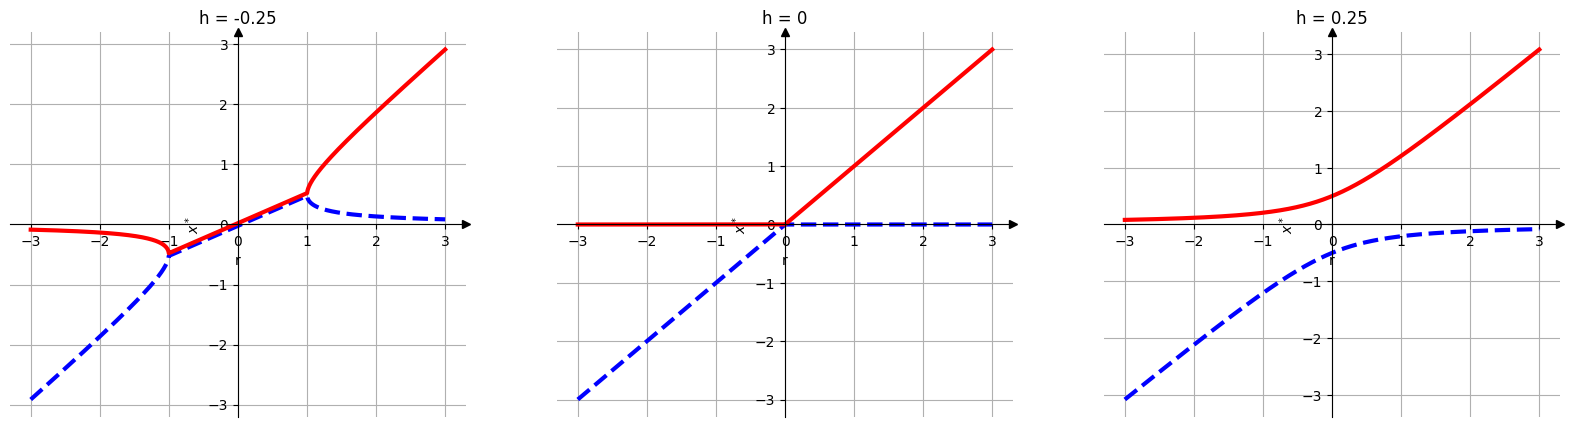

In [9]:
r = np.linspace(-3,3,2000)
H = [-0.25,0,0.25]
fig,ax=plt.subplots(1,3,figsize=(20,5))

for i,h in enumerate(H):

    D = r**2 + 4*h
    mask = D >= 0

    xp = (r[mask] + np.sqrt(D[mask]))/2
    xm = (r[mask] - np.sqrt(D[mask]))/2
    ax = plt.subplot(1,len(H), i+1)
    ax.plot(r[mask],xm,'--b',lw=3)
    ax.plot(r[mask],xp,'r',lw=3)
    ax.set_title(f"h = {h}")
    ax.set_xlabel("r")
    ax.set_ylabel(r"$x^*$")
    ax.grid()
    customize_axes(ax)
plt.show()

**(b) Regions in the $(r, h)$-plane**                                                                                                                         
A bifurcation occurs when                                                                                                                                   
$\qquad\displaystyle f(x) = 0, \qquad f'(x) = 0.$                                                                                                                               
Since                                                                                                                                                                                                                                                  
$\qquad\displaystyle f'(x) = r - 2x,$                                                                                                                                                                                                                                                  
we have                                                                                                                                                     
$\qquad\displaystyle x = \frac{r}{2}.$                                                                                                                                        
Substituting into $f(x) = 0$,                                                                                                                                
$\qquad\displaystyle h + r\left(\frac{r}{2}\right) - \left(\frac{r}{2}\right)^2 = 0,$                                                                                                                         
which gives                                                                                                                                              
$\qquad\displaystyle h + \frac{r^2}{4} = 0.$                                                                                                                                                                                                                                                  
Hence the bifurcation set is                                                                                                                                                                                                                                                  
$\qquad\displaystyle h = -\frac{r^2}{4}.$                                                                                                                                                                                                                                                  
This is a parabola in the $(r, h)$-plane.

$$\begin{array}{|c|c|c|}
\hline
\textbf{Parameter Region} & \textbf{Condition} & \textbf{Number of Equilibria} \\
\hline
\textbf{Region I} & h > -\dfrac{r^2}{4} & 2 \text{ equilibria (One stable, one unstable)} \\
\hline
\textbf{Boundary} & h = -\dfrac{r^2}{4} & 1 \text{ equilibrium (Saddle-node double root)} \\
\hline
\textbf{Region II} & h < -\dfrac{r^2}{4} & 0 \text{ equilibria} \\
\hline
\end{array}$$


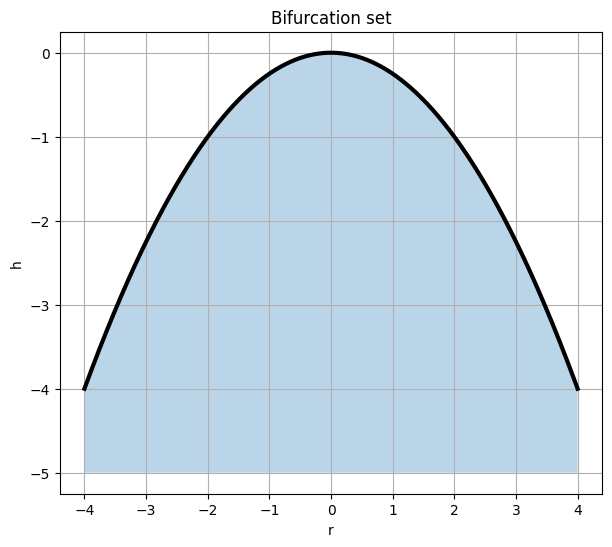

In [10]:
r = np.linspace(-4,4,1000)
h = -r**2/4
plt.figure(figsize=(7,6))
plt.plot(r,h,'k',lw=3)
plt.fill_between(r,h,-5,alpha=0.3)
plt.xlabel('r')
plt.ylabel('h')
plt.title('Bifurcation set')
plt.grid()
plt.show()

**(c) Potential function**                                                                                                                                   
Since                                                                                                                                                             
$\qquad\displaystyle \dot x = f(x),$                                                                                                                                                                                                                                                                    
define $V(x)$ by                                                                                                                                                                                                                                                                    
$\qquad\displaystyle \dot x = -\frac{dV}{dx}.$                                                                                                                                                                                                                                                                  
Thus                                                                                                                                                                                                                                                                    
$\qquad\displaystyle -\frac{dV}{dx} = h + rx - x^2.$                                                                                                                                                                                                                                                            
Hence                                                                                                                                                                                                                                                                    
$\qquad\displaystyle \frac{dV}{dx} = -h - rx + x^2.$                                                                                                                                  
Integrating,                                                                                                                                                                                                                                                                    
$\qquad\displaystyle V(x) = -hx - \frac{r}{2}x^2 + \frac{1}{3}x^3 + C.$                                                                                                                                  
Ignoring the additive constant,                                                                                                                                  
$\qquad\displaystyle V(x) = \frac{1}{3}x^3 - \frac{r}{2}x^2 - hx.$

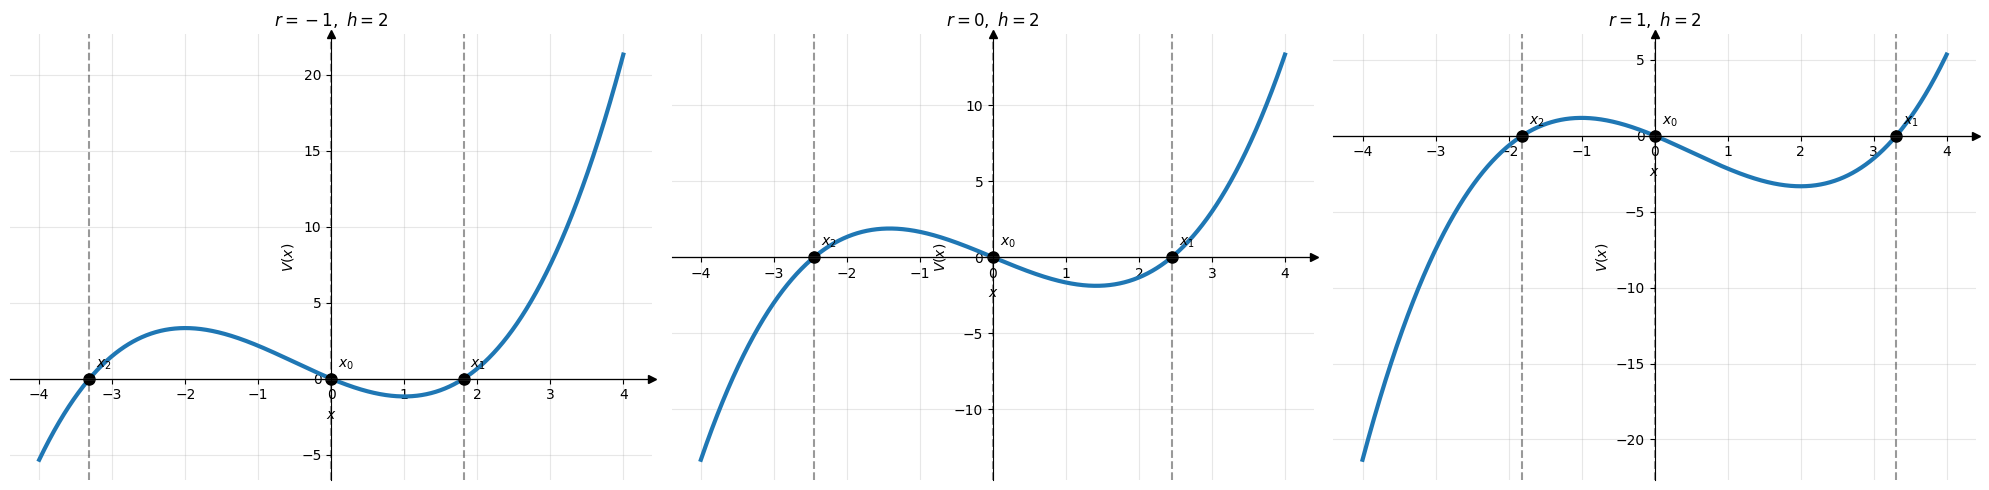

In [11]:
x = np.linspace(-4,4,2000)
h = 2
cases = [-1,0,1]

def V(x,r,h):
    return -h*x - 0.5*r*x**2 + x**3/3

def Vroots(r,h):
    D = 9*r**2 + 48*h
    x1 = 0.0
    x2 = (3*r + np.sqrt(D))/4
    x3 = (3*r - np.sqrt(D))/4
    return [x1, x2, x3]

fig, ax = plt.subplots(1,3,figsize=(20,5))
for i,r in enumerate(cases):
    Vx = V(x,r,h)
    ax[i].plot(x,Vx,lw=3,label=r'$V(x)$')
    roots = Vroots(r,h)
    for j,xr in enumerate(roots):
        ax[i].plot(xr,0,'ko',ms=8)
        ax[i].axvline(xr,color='k',ls='--',alpha=0.4)
        ax[i].annotate(fr'$x_{j}$',(xr,0),xytext=(5,8),textcoords='offset points')
    ax[i].axhline(0,color='gray',lw=1)
    ax[i].set_title(fr"$r={r},\ h={h}$")
    ax[i].set_xlabel(r"$x$")
    ax[i].set_ylabel(r"$V(x)$")
    ax[i].grid(alpha=0.3)
    customize_axes(ax[i])
plt.tight_layout()
plt.show()

**3.6.3**  <span style="color:red">(A perturbation to the supercritical pitchfork)                                                                                                  
Consider the system $\displaystyle\dot{x} = rx+ax^2−x^3$, where $-\infty<u<\infty$.                                                                                   
When $a = 0$, we have the normal form for the supercritical pitchfork.                                                                                        
The goal of this exercise is to study the effects of the new parameter $a$.                                                                                      
a) For each $a$, there is a bifurcation diagram of $x^{*}$ vs. $r$.                                                                                                 
$\quad$As $a$ varies, these bifurcation diagrams can undergo qualitative changes.                                                                                   
$\quad$Sketch all the qualitatively different bifurcation diagrams that can be obtained by varying $a$.                                                                       
b) Summarize your results by plotting the regions in the $( r, a )$ plane that correspond 
to qualitatively different classes of vector fields.                 
$\quad$ Bifurcations occur o 
the boundaries of these regions; identify the types of bifurcations that occu<span>



**(a) Bifurcation diagrams $x^*$ vs $r$**

$\qquad\displaystyle \dot{x}=f(x)=rx+ax^2-x^3$                                                                                                                                                                                                 
***Step 1: Equilibria***                                                                                                                                                                                                
Set                                                                                                                                                                                                
$\qquad\qquad\displaystyle f(x) = 0.$                                                                                                                                                                                                
Then                                                                                                                                                                                                
$\qquad\qquad\displaystyle rx + ax^2 - x^3 = 0,$                                                                                                                                                                                                
or $\qquad\qquad\displaystyle x(r + ax - x^2) = 0.$                                                                                                                                                                                                
Hence                                                                                                                                                                                                
$\qquad\qquad\displaystyle x_0 = 0$                                                                                                                                                        
and                                                                                                                                                        
$\qquad\qquad\displaystyle x^2 - ax - r = 0.$                                                                                                                                                        
Therefore                                                                                                                                                        
$\qquad\qquad\displaystyle x_{\pm} = \frac{a \pm \sqrt{a^2 + 4r}}{2}.$                                                                                                                                                        
The nontrivial equilibria exist when                                                                                                                                                        
$\qquad\qquad\displaystyle a^2 + 4r \ge 0,$                                                                                                                                                        
i.e. $\qquad\qquad\displaystyle r \ge -\frac{a^2}{4}.$                                                                                                                                                        
***Step 2: Stability***                                                                                                                                                        
$\qquad\qquad\displaystyle f'(x) = r + 2ax - 3x^2.$                                                                                                                                                        
Branch $x = 0$                                                                                                                                                        
$\qquad\qquad\displaystyle f'(0) = r.$                                                                                                                                                        
Thus                                                                                                                                                        
$\qquad\qquad\displaystyle x = 0 \text{ stable if } r < 0,$                                                                                                                                                        
$\qquad\qquad\displaystyle x = 0 \text{ unstable if } r > 0.$                                                                                                                                                        
***Nontrivial branches***                                                                                                                                                       
Since                                                                                                                                                        
$\qquad\qquad\displaystyle r = x^2 - ax,$                                                                                                                                                        
substitute into $f'(x)$:                                                                                                                                                        
$\qquad\qquad\displaystyle f'(x) = (x^2 - ax) + 2ax - 3x^2 = ax - 2x^2.$                                                                                                                                                        
Hence                                                                                                                                                        
$\qquad\qquad\displaystyle f'(x) = x(a - 2x).$                                                                                                                                                        
Using                                                                                                                                                        
$\qquad\qquad\displaystyle x_{\pm} = \frac{a \pm \sqrt{a^2 + 4r}}{2},$                                                                                                                                                        
we obtain                                                                                                                                                        
$\qquad\qquad\displaystyle a - 2x_{\pm} = \mp\sqrt{a^2 + 4r}.$                                                                                                                                                        
Therefore                                                                                                                                                        
$\qquad\qquad\displaystyle f'(x_+) = -x_+\sqrt{a^2 + 4r},$                                                                                                                                                        
$\qquad\qquad\displaystyle f'(x_-) = x_-\sqrt{a^2 + 4r}.$                                                                                                                                                        
The stability follows immediately.                                                                                                                                                        
**Case 1: $a = 0$**                                                                                                                                                        
Then                                                                                                                                                        
$\qquad\qquad\displaystyle \dot x = rx - x^3.$                                                                                                                                                        
Equilibria:                                                                                                                                                        
$\qquad\qquad\displaystyle x = 0, \qquad x = \pm\sqrt{r}.$                                                                                                                                                        
For $r < 0, x = 0$ is stable.                                                                                                                                                        
For $r > 0, x = 0$ becomes unstable and two stable equilibria appear.                                                                                                                                                        
Hence it is a supercritical pitchfork.                                                                                                                                                        
**Case 2: $a > 0$**                                                                                                                                                        
The nontrivial branches meet at                                                                                                                                                        
$\qquad\qquad\displaystyle r = -\frac{a^2}{4}, \qquad x = \frac{a}{2}.$                                                                                                                                                        
This is a saddle-node bifurcation.                                                                                                                                                        
The positive branch exists before $r = 0$.                                                                                                                                                        
At $r = 0 , x = 0$ and $x = a$ coexist.                                                                                                                                                        
Thus the pitchfork is broken.                                                                                                                                                        
The bifurcation diagram contains:                                                                                                                                                        
* a saddle-node at $ \displaystyle \left(-\frac{a^2}{4}, \frac{a}{2}\right)$,
* a transcritical exchange at $(0, 0)$.

Hence the diagram looks like an imperfect pitchfork tilted to the right.                                                                                                                                                        
**Case 3: $a < 0$**                                                                                                                                                        
Now the saddle-node occurs at $ \displaystyle \left(-\frac{a^2}{4}, \frac{a}{2}\right)$ on the negative-$x$ side.                                                                                                                                                        
Again there is a transcritical bifurcation at $r = 0.$                                                                                                                                                        
The diagram is the mirror image of the $a > 0$ case.r.

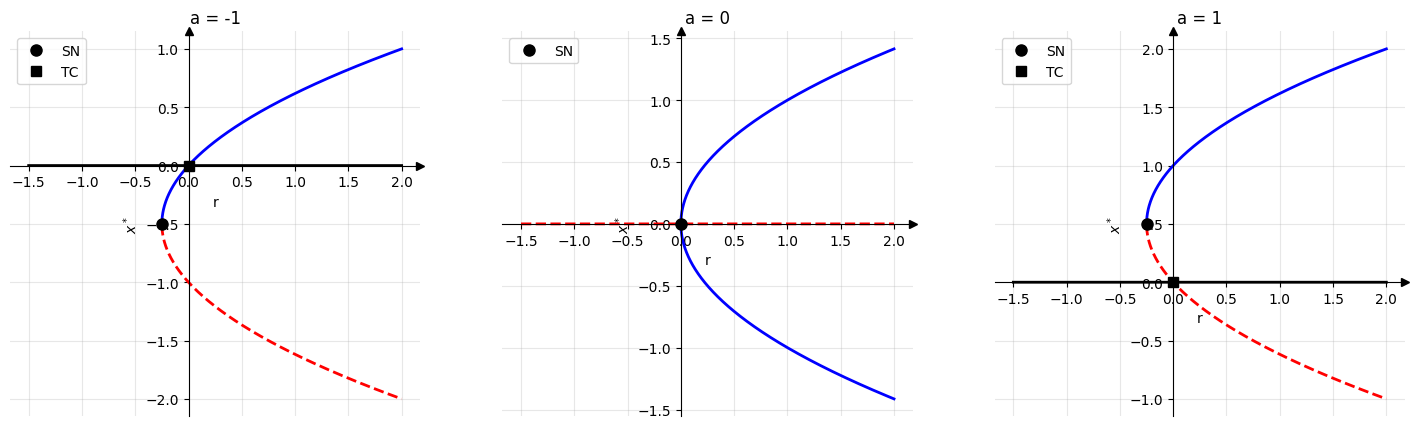

In [12]:
def x_plus(r, a):
    return (a + np.sqrt(a**2 + 4*r))/2

def x_minus(r, a):
    return (a - np.sqrt(a**2 + 4*r))/2

def saddle_node(a):
    r_sn = -a**2/4
    x_sn = a/2
    return r_sn, x_sn

def transcritical():
    return 0.0, 0.0
    
a_values = [-1, 0, 1]
r = np.linspace(-1.5, 2, 2000)
fig, ax = plt.subplots(1,3, figsize=(18,5))
for i,a in enumerate(a_values):
    ax[i].axhline(0,color='k',lw=0.5)
    ax[i].axvline(0,color='k',lw=0.5)
    if a == 0:
        rp = r[r >= 0]
        ax[i].plot(r, np.zeros_like(r), 'r--', lw=2)
        ax[i].plot(rp, np.sqrt(rp), 'b', lw=2)
        ax[i].plot(rp, -np.sqrt(rp), 'b', lw=2)
        ax[i].plot(0,0,'ko',ms=8, label='SN')
    else:
        rmin = -a**2/4
        rr = r[r >= rmin]
        xp = x_plus(rr,a)
        xm = x_minus(rr,a)
        ax[i].plot(r, np.zeros_like(r),'k',lw=2)
        ax[i].plot(rr,xp,'b',lw=2)
        ax[i].plot(rr,xm,'r--',lw=2)
        rsn,xsn = saddle_node(a)
        ax[i].plot(rsn,xsn,'ko',ms=8,label='SN')
        ax[i].plot(0,0,'ks',ms=7,label='TC')
    ax[i].set_title(f"a = {a}")
    ax[i].set_xlabel("r")
    ax[i].set_ylabel(r"$x^*$")
    ax[i].grid(alpha=0.3)
    ax[i].legend()
    customize_axes(ax[i])
plt.show()

**(b) Parameter plane $(r, a)$**                                                                                                                                                       
The equilibria satisfy                                                                                                                                                       
$\qquad\qquad\displaystyle x(r + ax - x^2) = 0.$                                                                                                                                                       
Bifurcations occur when                                                                                                                                                       
$\qquad\qquad\displaystyle f = 0, \qquad f_x = 0.$                                                                                                                                                       
**Saddle-node curve**                                                                                                                                                       
For $x \neq 0$,                                                                                                                                                       
$\qquad\qquad\displaystyle r + ax - x^2 = 0,$                                                                                                                                                       
and                                                                                                                                                       
$\qquad\qquad\displaystyle r + 2ax - 3x^2 = 0.$                                                                                                                                                       
Subtracting,                                                                                                                                                       
$\qquad\qquad\displaystyle ax - 2x^2 = 0.$                                                                                                                                                       
Thus                                                                                                                                                       
$\qquad\qquad\displaystyle x = \frac{a}{2}.$                                                                                                                                                       
Substituting into                                                                                                                                                       
$\qquad\qquad\displaystyle r = x^2 - ax,$                                                                                                                                                       
gives                                                                                                                                                       
$\qquad\qquad\displaystyle r = \frac{a^2}{4} - \frac{a^2}{2} = -\frac{a^2}{4}.$                                                                                                                                                       
Hence                                                                                                                                                       
$\qquad\qquad\displaystyle r = -\frac{a^2}{4}.$                                                                                                                                                       
This is a parabola.                                                                                                                                                       
**Transcritical curve**                                                                                                                                                       
Since $x = 0$ exists for all parameters,                                                                                                                                                       
$\qquad\qquad\displaystyle f_x(0) = r.$                                                                                                                                                       
Thus $r = 0$ is another bifurcation curve.                                                                                                                          
                                                                                                                                                       **Codimension-two point**                                                                                                                                                       
The curves                                                                                                                                                       
$\qquad\qquad\displaystyle r = 0, \qquad r = -\frac{a^2}{4}$                                                                                                                                                       
meet at $(r, a) = (0, 0).$                                                                                                                                                       
This is the organizing center of the unfolding.                                                                                                                                

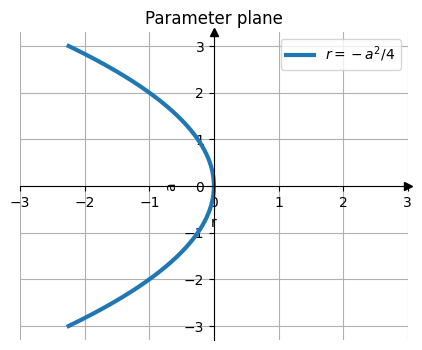

In [13]:
a = np.linspace(-3,3,2000)
r = -a**2/4

fig,ax=plt.subplots(figsize=(5,4))
ax.plot(r,a,lw=3,label=r'$r=-a^2/4$')
ax.set_xlabel('r')
ax.set_ylabel('a')
ax.set_title('Parameter plane')
ax.legend()
ax.grid()
ax.set_xlim(a.min(), a.max())
customize_axes(ax)
plt.show()

**3.6.4**  <span style="color:red">(Imperfect saddle-node)                                                                                                                                   
What happens if you add a small imperfection to a system that has a saddle-node bifurcation ?<span>

Let the imperfection be a constant term $h$                                                                                                                                                       
$\qquad\qquad\displaystyle \dot x = r + h + x^2.$                                                                                                                                                       
The equilibria satisfy                                                                                                                                                       
$\qquad\qquad\displaystyle r + h + x^2 = 0.$                                                                                                                                                       
Hence                                                                                                                                                       
$\qquad\qquad\displaystyle x^* = \pm\sqrt{-(r + h)}.$                                                                                                                                                       
Real equilibria exist when                                                                                                                                                       
$\qquad\qquad\displaystyle r + h \le 0.$                                                                                                                                                       
The fold occurs when                                                                                                                                                       
$\qquad\qquad\displaystyle r + h = 0,$                                                                                                                                                       
or $ \qquad \displaystyle  \boxed{r = -h}$

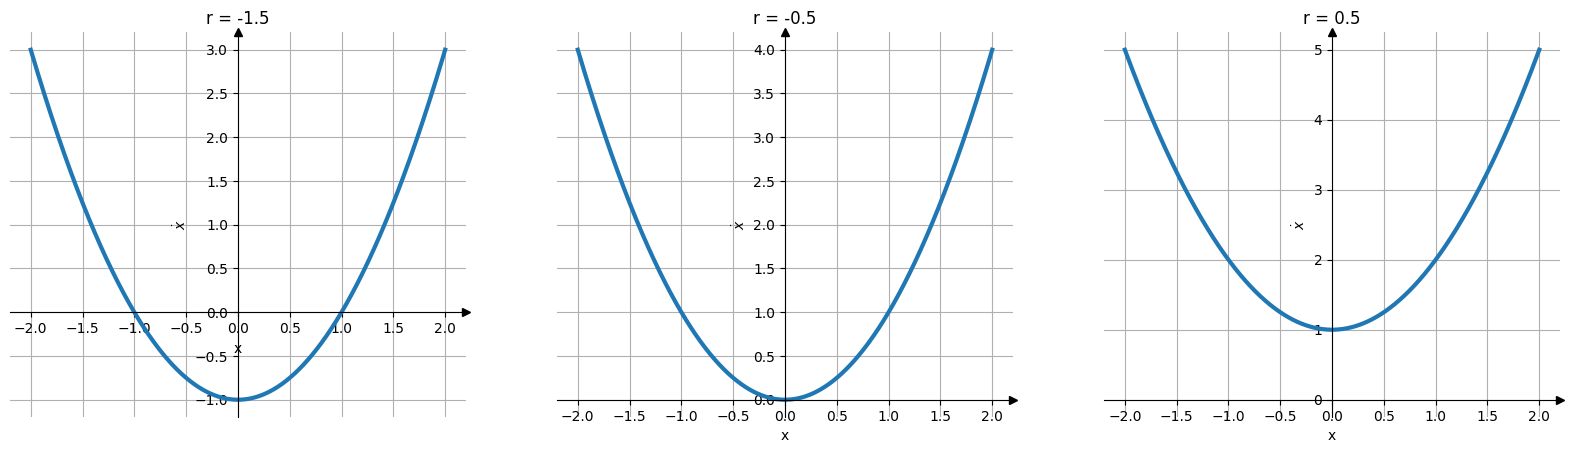

In [14]:
x = np.linspace(-2,2,1000)
h = 0.5
R = [-1.5,-0.5,0.5]
fig=plt.figure(figsize=(20,5))

for i,r in enumerate(R):
    f = h + r + x**2
    ax = plt.subplot(1,len(R), i+1)
    ax.plot(x,f,lw=3)
    ax.set_title(f"r = {r}")
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\dot{x}$")
    customize_axes(ax)
    ax.grid()
plt.show()

**3.6.5**  <span style="color:red">(Mechanical example of imperfect bifurcation and catastrophe)                                                                                                   
Consider the bead on a tilted wire discussed at the end of Section 3.6.                                                                                        
a) Show that the equilibrium positions of the bead satisfy                                                                                                  
$ \qquad\qquad\displaystyle mg\,\sin\theta= kx\Bigg(1-\frac{L_{\tiny 0}}{\sqrt{x^2+a^2}}\Bigg)$                                                                     
b) Show that this equilibrium equation can be written in dimensionless form as                                                                                 
$\qquad \qquad\displaystyle 1-\frac{h}{u}=\frac{R}{\sqrt{1+u^2}}$                                                                                                  
$\quad$for appropriate choices of $R, h,$ and $u$.                                                                                                              
c) Give a graphical analysis of the dimensionless equation for the cases $R < 1$ and $R > 1$.                                                                   
$\quad$How many equilibria can exist in each case?                                                                                                                     
d) Let $r = R - 1$. Show that the equilibrium equation reduces to $h+ru−\frac12 u^3 \approx 0$ for small $r, h,$ and $u$.                                      
e) Find an approximate formula for the saddle-node bifurcation curves in the limit of small $r, h,$ and $u$.                                                   
f) Show that the *exact* equations for the bifurcation curves can be written in parametric form as                                                           
$ \qquad\displaystyle h ( u ) = -u^3 \;\;,\qquad R ( u ) = (l + u^2 )^{3 / 2}\;\;,$                                                                                     
$\quad$where $-\infty<u<\infty$. (Hint: You may want to look at Section 3.7.)                                                                                      
$\quad$Check that this result reduces to the approximate result in part (d).                                                                                              
g) Give a numerically accurate plot of the bifurcation curves in the $( r, h )$ plane.                                                                           
h) Interpret your results physically, in terms of the original dimensional variables.<span>


**(a) Equilibrium equation**                                                                                                                                    
The spring length is                                                                                                                                                                                                
$\qquad\qquad\displaystyle L = \sqrt{x^2+a^2}.$                                                                                                                                                                                                
The spring force magnitude is                                                                                                                                                                                                
$\qquad\qquad\displaystyle F_s = k(L-L_0).$                                                                                                                                                                                                
Its component along the wire is                                                                                                                                                                                                
$\qquad\qquad\displaystyle F_x = -k(L-L_0)\frac{x}{L}.$                                                                                                                                                                                                
Hence                                                                                                                                                                                                
$\qquad\qquad\displaystyle F_x = -k\left(\sqrt{x^2+a^2}-L_0\right) \frac{x}{\sqrt{x^2+a^2}}.$                                                                                                
Equilibrium requires                                                                                                                                                                                                
$\qquad\qquad\displaystyle mg\sin\theta + F_x = 0.$                                                                                                                                                                                                
Therefore                                                                                                                                                                                                
$\qquad\qquad\boxed{\displaystyle mg\sin\theta = kx \left( 1-\frac{L_0}{\sqrt{x^2+a^2}} \right)}$                                                                                                                                                                                                

**(b) Dimensionless form**                                                                                                                                                  
Define                                                                                                                                                   
$\qquad\qquad\displaystyle u = \frac{x}{a}, \qquad R = \frac{L_0}{a}, \qquad h = \frac{mg\sin\theta}{ka}.$                                                                                                                                                  
Then                                                                                                                                                      
$\qquad\qquad\displaystyle x = au,$                                                                                                                                                  
and
$\qquad \displaystyle \sqrt{x^2+a^2} = a\sqrt{1+u^2}.$                                                                                                                                                  
Substituting into (a),                                                                                                                                                  
$\qquad \qquad\displaystyle h = u \left( 1-\frac{R}{\sqrt{1+u^2}} \right).$                                                                                                                                                  
Divide by $u$                                                                                                                                                  
$\qquad\qquad\displaystyle \frac{h}{u} = 1-\frac{R}{\sqrt{1+u^2}}.$                                                                                                                                                  
Hence                                                                                                                                                     
$\qquad\qquad\boxed{\displaystyle 1-\frac{h}{u} = \frac{R}{\sqrt{1+u^2}}}$

**(c) Graphical analysis**                                                                                                                                                 
Consider                                        
$\qquad\qquad\displaystyle 1-\frac{h}{u} = \frac{R}{\sqrt{1+u^2}}.$                                                                                                                                                 
Define                                                                                                                                                     
$\qquad\qquad\displaystyle y_1(u) = 1-\frac{h}{u}, \qquad y_2(u) = \frac{R}{\sqrt{1+u^2}}.$

$$\begin{array}{c|c}
\hline
\textbf{Case: } R < 1 & \textbf{Case: } R > 1 \\
\hline
\begin{array}{c}
y_2(0) = R < 1 \\
\text{Curve lies entirely below } 1 \\
\text{The intersections are unique} \\
\textbf{One equilibrium } \text{for any small } h
\end{array}
&
\begin{array}{c}
y_2(0) = R > 1 \\
\text{Curve starts above } 1 \text{ and decreases to } 0 \\
\text{Depending on } h\text{, there may be } 1, 2, \text{ or } 3 \text{ intersections} \\
\textbf{Up to three equilibria } \text{ can exist} \\
\text{The transition occurs through saddle-node bifurcations}
\end{array} \\
\hline
\end{array}$$


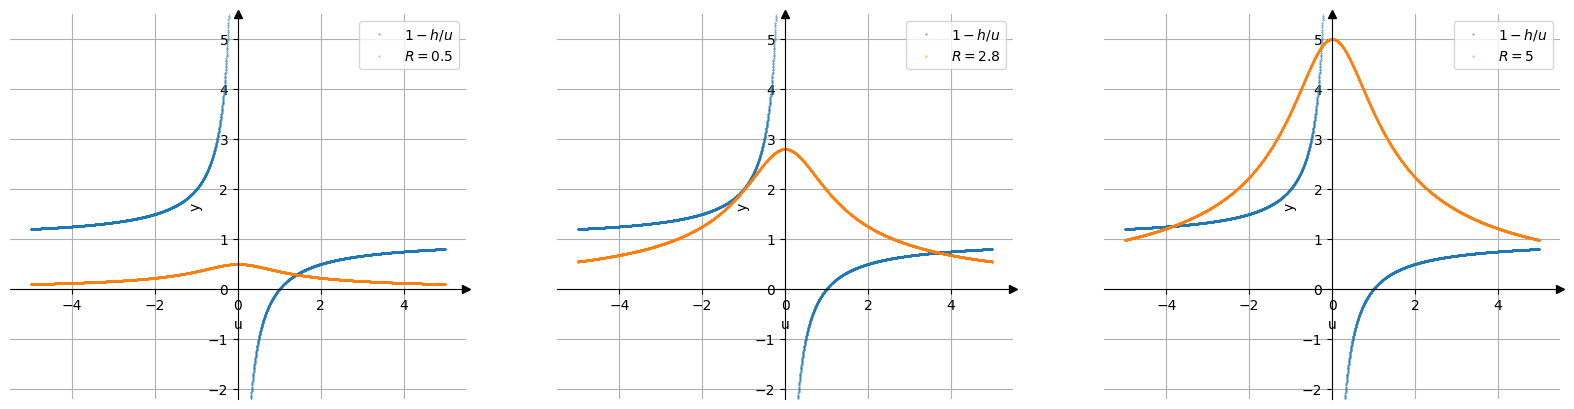

In [15]:
u = np.linspace(-5,5,4000)
u = u[np.abs(u)>1e-3]
h = 1
R_vals = [0.5, 2.8, 5]
fig=plt.figure(figsize=(20,5))

for i,R in enumerate(R_vals):
    ax = plt.subplot(1,len(R_vals), i+1)
    ax.plot(u,1-h/u,'.',ms=0.7,label=r'$1-h/u$')
    ax.plot(u,R/np.sqrt(1+u**2),'.',ms=0.7,label=rf'$R={R}$')
    ax.legend()
    ax.grid()
    customize_axes(ax)
    ax.set_ylim(-2.2,5.5)
    ax.set_xlabel('u')
    ax.set_ylabel('y')
plt.show()

**(d) Reduction near the critical point**                                                                                                                                                  
Set                                                                                                                                                      
$\qquad\qquad\displaystyle R = 1+r,$                                                                                                                                                  
with                                                                                                                                                     
$\qquad\qquad\displaystyle \vert{}r\vert{} \ll 1, \qquad \vert{}u\vert{} \ll 1.$                                                                                                                                                  
Expand                                                                                                                                                    
$\qquad\qquad\displaystyle \frac{1}{\sqrt{1+u^2}} = 1-\frac12u^2+O(u^4).$                                                                                                                                                  
Hence                                                                                                                                                    
$\qquad\qquad\displaystyle 1-\frac{h}{u} = (1+r)\left(1-\frac12u^2\right).$                                                                                                                                                  
Ignoring higher-order terms,                                                                                                                                                  
$\qquad\qquad\displaystyle 1-\frac{h}{u} = 1+r-\frac12u^2.$                                                                                                                                                  
Subtract $1$:                                                                                                                                                  
$\qquad\qquad\displaystyle -\frac{h}{u} = r-\frac12u^2.$                                                                                                                                                  
Multiply by $u$:                                                                                                                                                  
$\qquad\qquad\displaystyle -h = ru-\frac12u^3.$                                                                                                                                                  
Therefore                                                                                                                                                  
$\qquad\qquad\displaystyle h+ru-\frac12u^3 \approx 0$                                                                                                                                                  
which is the imperfect pitchfork normal form.






$\qquad\qquad\displaystyle 1-\frac{h}{u}=\frac{R}{\sqrt{1+u^2}}$

$\qquad\qquad\displaystyle R = 1+r,$                                                                                                                                                  
$\qquad\qquad\displaystyle 1-\frac{h}{u}= \frac{u-h}{u}=\frac{1+r}{\sqrt{1+u^2}}$

$\qquad\qquad\displaystyle u\sqrt{1+u^2} -h\sqrt{1+u^2}= (1+r)u$

$\qquad\qquad\displaystyle h\sqrt{1+u^2}+(1+r)u -u\sqrt{1+u^2}=0$

Taylor series expansion

$\qquad\qquad\displaystyle h\left(1+\frac12 u^2 + O(u^4)\right)+(1+r)u -u\left(1+\frac12 u^2 + O(u^4)\right)=0$

$\qquad\qquad\displaystyle h +\frac{h}{2} u^2 + u + ru -u-\frac{1}{2}u^3= O(u^4) $

$\qquad\qquad\displaystyle h +\frac{h}{2} u^2 + ru  -\frac{1}{2}u^3\approx 0 $


**(e) Approximate saddle-node curves**

The saddle-node bifurcations will occur approximately at the local maximum of the approximate equation                                                   
when the slopes of these equations are equal at an equal height.

$\qquad\qquad\displaystyle h +\frac{h}{2} u^2 =\frac{1}{2}u^3- ru $

* $\qquad\qquad\displaystyle \frac{d}{du}\left(h +\frac{h}{2} u^2\right) =\frac{d}{du}\left(\frac{1}{2}u^3- ru\right)  $

$\qquad\qquad\displaystyle hu = \frac32u^2-r$

$\qquad\qquad\displaystyle r = \frac32u^2-hu$

* $\qquad\qquad\displaystyle h +\frac{h}{2} u^2 =\frac{1}{2}u^3- ru = \frac{1}{2}u^3-\left(\frac32u^2-hu\right)u = \frac{1}{2}u^3- \frac32u^3+hu^2 =-u^3+hu^2$

$\qquad\qquad\displaystyle u^3 = -h -\frac{h}{2} u^2+hu^2=\frac{h}{2} u^2-h= h\left(\frac{1}{2} u^2-1\right)$

$\qquad\qquad\displaystyle h=\frac{2u^3}{u^2-2}$

$\qquad\qquad\displaystyle r = \frac32u^2-hu = \frac32u^2-\frac{2u^3}{u^2-2}u = \frac32u^2-\frac{2u^4}{u^2-2} =\frac{3u^2(u^2-2)-4u^4}{2(u^2-2)} $


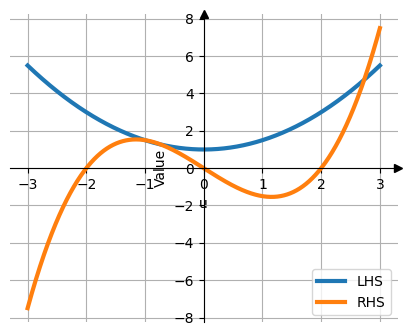

In [16]:
h = 1
r = 2
u = np.linspace(-3,3,2000)
lhs = h + 0.5*h*u**2
rhs = 0.5*u**3 - r*u 

fig,ax=plt.subplots(figsize=(5,4))
ax.plot(u,lhs,lw=3,label='LHS')
ax.plot(u,rhs,lw=3,label='RHS')
ax.axhline(0,color='k',lw=0.5)
ax.axvline(0,color='k',lw=0.5)
plt.xlabel('u')
plt.ylabel('Value')
#plt.title(r'$h+ru+\frac{h}{2}u^2=\frac12u^3$')
ax.grid(True)
ax.legend()
customize_axes(ax)
plt.show()

**(f) Exact bifurcation curves**

Start from                                                                                                                                                     
$\qquad\qquad\displaystyle F(u,h,R) = 1-\frac{h}{u} -\frac{R}{\sqrt{1+u^2}} = 0.$                                                                                                                                                     
At a saddle-node,                                                                                                                                                     
$\qquad\qquad\displaystyle F = 0, \qquad \frac{\partial F}{\partial u} = 0.$                                                                                                                                                     
Differentiating,                                                                                                                                                     
$\qquad\qquad\displaystyle \frac{h}{u^2} + \frac{Ru}{(1+u^2)^{3/2}} = 0.$                                                                                                                                                     
Using                                                                                                                                                     
$\qquad\qquad\displaystyle R = \sqrt{1+u^2}\left(1-\frac{h}{u}\right),$                                                                                                                                                     
substitute into the derivative condition:                                                                                                                                                     
$\qquad\qquad\displaystyle \frac{h}{u^2} + \frac{u}{1+u^2} \left(1-\frac{h}{u}\right) = 0.$                                                                                                                                                     
Multiplying by $u^2(1+u^2)$,                                                                                                                                                     
$\qquad\qquad\displaystyle h(1+u^2)+u^3-hu^2 = 0.$                                                                                                                                                     
Thus                                                                                                                                                     
$\qquad\qquad\displaystyle h = -u^3.$                                                                                                                                                     
Substituting into the equilibrium equation,                                                                                                                                                     
$\qquad\qquad\displaystyle 1+u^2 = \frac{R}{\sqrt{1+u^2}}.$                                                                                                                                                     
Therefore                                                                                                                                                     
$\qquad\qquad\displaystyle R = (1+u^2)^{3/2}$                                                                                                                                                        
***Reduction to the approximate result***                                                                                                                                                     
For small $u$,                                                                                                                                                     
$\qquad\qquad\displaystyle R = (1+u^2)^{3/2} = 1+\frac32u^2+O(u^4).$                                                                                                                                                     
Hence                                                                                                                                                     
$\qquad\qquad\displaystyle r = R-1 = \frac32u^2+O(u^4).$                                                                                                                           


**(g) Exact bifurcation curve in $(r,h)$**

Since                                                                                                                                                         
$\qquad\qquad\displaystyle r = R-1,$                                                                                                                       
the exact parametric representation is                                                                                                                                                                        
$\qquad\qquad\displaystyle r(u) = (1+u^2)^{3/2}-1, \qquad h(u) = -u^3,  R(u) = (1 + u^2)^{ 3/2}.$                                                                                                           
The curve is a symmetric cusp with tip at                                                                                                                                  
$\qquad\qquad\displaystyle (r,h) = (0,0).$ 



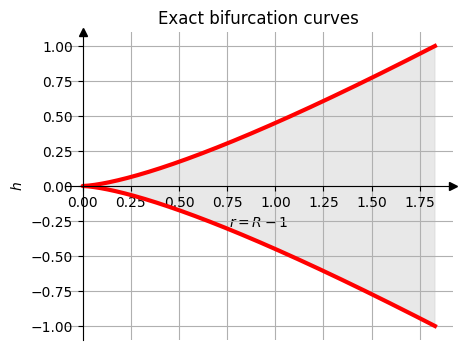

In [17]:
u = np.linspace(-1,1,4000)
h = -u**3
r = (1+u**2)**1.5 - 1

fig,ax=plt.subplots(figsize=(5,4))

plt.plot(r,h,'r',lw=3)
plt.fill(r,h,color='lightgray',alpha=0.5)
plt.xlabel(r'$r=R-1$')
plt.ylabel(r'$h$')
plt.title('Exact bifurcation curves')
plt.grid()
customize_axes(ax)
plt.show()

**(h) Physical interpretation**

$h(u)=-u^3, \;\; R(u)=(1+u^2)^{3/2},\;\; u =\frac{x}{a}$

$r = \frac{L_0}{a}-1, \qquad h = -\left(\frac{x}{a}\right)^3 = \frac{mg\sin\theta}{ka}.$

Thus

* $r$ measures how much longer the spring's natural length is than the geometric distance $a$.
* $h$ measures the gravitational tilt force relative to the spring force.

For $r < 0$, the spring is effectively short and only one equilibrium exists.

For $r > 0$, the spring can buckle to either side, creating three equilibria (two stable, one unstable).

The cusp curve separates regions with

$\begin{array}{c|c} \text{Outside cusp} & 1 \text{ equilibrium} \\ \hline \text{Inside cusp} & 3 \text{ equilibria} \end{array}$

Crossing the cusp corresponds to a sudden jump of the bead from one stable position to another—a mechanical realization of a cusp catastrophe.


**3.6.6**  <span style="color:red">(Patterns in fluids)                                                                                                                           
Ahlers (1989) gives a fascinating review of experiments on one-dimensional patterns in fluid systems.                                                          
In many cases, the patterns first emerge via supercritical or subcritical pitchfork bifurcations from a spatially uniform state.                               
Near the bifurcation, the dynamics of the amplitude of the patterns are given approximately by                                                                 
$\qquad \qquad\displaystyle \tau\dot{A} = \varepsilon A−gA^3$ in the supercritical case, or                                                               
$\qquad \qquad\displaystyle \tau\dot{A} = A−gA^3 −kA^5$ in the subcritical case.                                                                                                                
Here $A(t)$ is the amplitude, $\tau$ is a typical time scale, and $\varepsilon$ is a small dimensionless parameter that measures the distance from the bifurcation.                                                                                                                                                
The parameter $g > 0$ in the supercritical case, whereas $g < 0$ and $k > 0$ in the subcritical case.                                                                
(In this context, the equation $\displaystyle \tau\dot{A} = \varepsilon A−gA^3$ is often called the Landau equation.)                                                                           
a) Dubois and Bergé (1978) studied the supercritical bifurcation that arises in Rayleigh-Bénard convection,                                                      
$\quad$and showed experimentally that the steadystate amplitude depended on $\varepsilon$ according to the power law $A^{*} \propto \varepsilon^\beta$, where $\beta= 0.50 \pm 0.01$.                             
$\quad$What does the Landau equation predict?                                                                                                                          
b) The equation $\displaystyle \tau\dot{A} = \varepsilon A−gA^3 −kA^5$ is said to undergo a *tricritical bifurcation* when $g = 0;$                                                                   
$\quad$this case is the borderline between supercritical and subcritical bifurcations.                                                                             
$\quad$Find the relation between $A^{*}$ and $\varepsilon$ when $g = 0$.                                                                                                                             
c) In experiments on Taylor–Couette vortex flow, Aitta et al. (1985) were able to change the parameter $g$ continuously from positive to negative              
$\quad$by varying the aspect ratio of their experimental set-up.                                                                                          
$\quad$Assuming that the equation is modified to $\displaystyle \tau\dot{A} = h+ \varepsilon A−gA^3 −kA^5$ , where $h > 0$ is a slight imperfection,        
$\quad$sketch the bifurcation diagram of $A^{*}$ vs. $\varepsilon$ in the three cases $g > 0, g = 0$, and $g < 0 $.                                                          
$\quad$Then look up the actual data in Aitta et al. (1985, Figure 2) or see Ahlers (1989, Figure 15).                                                                  
d) In the experiments of part (c), the amplitude $A(t)$ was found to evolve toward a steady state in the manner shown in Figure 2                          
$\quad$(redrawn from Ahlers (1989), Figure 18).                                                                                                                   
$\quad$The results are for the imperfect subcritical case $g <0, h\ne 0$.                                                                                           
$\quad$In the experiments, the parameter $\varepsilon$ was switched at $t = 0$ from a negative value to a positive value $\varepsilon_f$ .                                                     
$\quad$In Figure 2, $\varepsilon_f$ increases from the bottom to the top.                                                                                                          
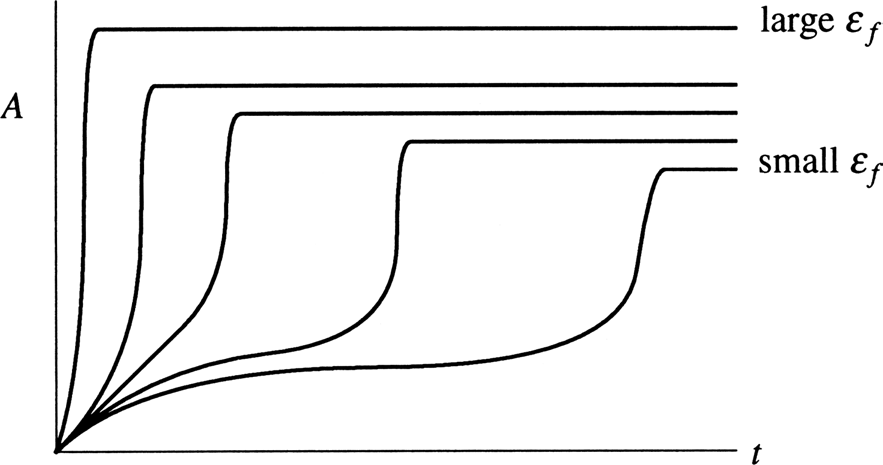                                                                                      
$\quad$Explain intuitively why the curves have this strange shape.                                                                                           
$\quad$Why do the curves for large $\varepsilon_f$ go almost straight up to their steady state,                                                                                
$\quad$whereas the curves for small $\varepsilon_f$ rise to a plateau before increasing sharply to their final level?                                                            
$\quad$(Hint: Graph $\dot{A}$ vs. $A$ for different $\varepsilon_f$ .)<span>


$\qquad\displaystyle\tau \dot A = f(A) = \varepsilon A - gA^3 - kA^5$                                                                                                          
Steady states satisfy , $f(A) = 0.$                                                                                                                               
Since $A$ is an amplitude, we usually take $A \ge 0$.

**(a) Supercritical case**                                                                                                                                        
The Landau equation is                                                                                                                                            
$\qquad \qquad\displaystyle\tau \dot A = \varepsilon A - gA^3, \qquad g > 0.$                                                                                        
The equilibria satisfy                                                                                                                                            
$\qquad \qquad\displaystyle A(\varepsilon - gA^2) = 0.$                                                                                                                                            
Hence                                                                                                                                                           
$\qquad \qquad\displaystyle A^* = 0,$                                                                                                                                            
or $\qquad \qquad\displaystyle A^{*2} = \frac{\varepsilon}{g}.$                                                                                                                                            
For $\varepsilon > 0$,                                                                                                                                            
$\qquad \qquad\displaystyle A^* = \sqrt{\frac{\varepsilon}{g}}.$                                                                                                                                            
Therefore                                                                                                                                                        
$\qquad \qquad\displaystyle A^* \propto \varepsilon^{1/2}.$                                                                                                                                            
So the critical exponent predicted by the Landau equation is                                                                                                                                            
$\qquad \qquad\displaystyle \beta = \frac{1}{2}.$                                                                                                                                            
This agrees with the experimental value                                                                                                                                            
$\qquad \qquad\displaystyle \beta = 0.50 \pm 0.01.$

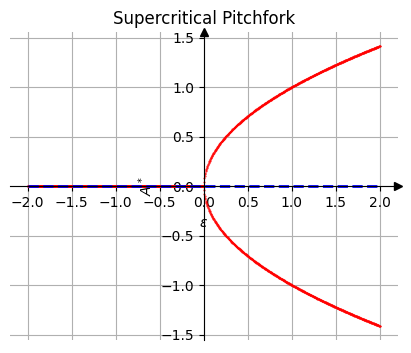

In [24]:
g = 1.0
eps = np.linspace(-2,2,1000)
A = np.sqrt(np.maximum(eps,0)/g)
fig,ax=plt.subplots(figsize=(5,4))
ax.plot(eps,A,'.r',ms=0.9,label='stable')
ax.plot(eps,-A,'.r',ms=0.9)
ax.plot(eps,np.zeros_like(eps),'b--',lw=2)
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel(r'$A^*$')
ax.set_title('Supercritical Pitchfork')
ax.grid()
customize_axes(ax)
plt.show()

**(b) Tricritical case ($g = 0$)**                                                                                                                                            
Now                                                                                                                                                       
$\qquad \qquad\displaystyle \tau \dot A = \varepsilon A - kA^5.$                                                                                                                                            
The steady states satisfy                                                                                                                                            
$\qquad \qquad\displaystyle A(\varepsilon - kA^4) = 0.$                                                                                                                                            
Hence                                                                                                                                                      
$\qquad \qquad\displaystyle A^* = 0$                                                                                                                                                     
or $\qquad \qquad\displaystyle A^{*4} = \frac{\varepsilon}{k}.$                                                                                                                                            
Thus for $\varepsilon > 0$,                                                                                                                                            
$\qquad \qquad\displaystyle A^* = \left(\frac{\varepsilon}{k}\right)^{1/4}.$                                                                                                                                            
Therefore                                                                                                                                                     
$\qquad \qquad\displaystyle A^* \propto \varepsilon^{1/4}.$                                                                                                                                            
The tricritical exponent is                                                                                                                                            
$\qquad \qquad\displaystyle \beta = \frac{1}{4}.$

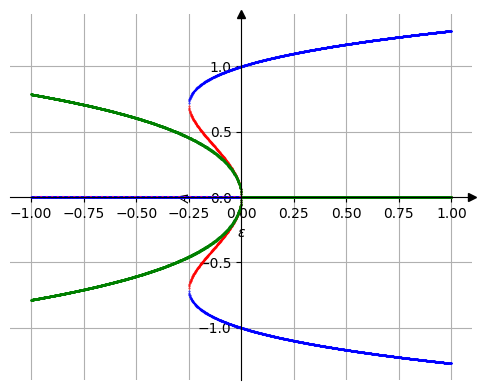

In [72]:
k = 1.0
eps = np.linspace(-1, 1, 2000)

fig, ax = plt.subplots(figsize=(5,4))

g = 1.0

stable_E, stable_A = [], []
unstable_E, unstable_A = [], []

for e in eps:
    roots = np.roots([-k, 0, g, 0, e, 0])

    for r in roots:
        if abs(r.imag) < 1e-8:
            A = r.real

            lam = e + 3*g*A**2 - 5*k*A**4

            if lam < 0:
                stable_E.append(e)
                stable_A.append(A)
            else:
                unstable_E.append(e)
                unstable_A.append(A)

ax.plot(stable_E, stable_A, '.b', ms=0.8, label='Stable')
ax.plot(unstable_E, unstable_A, '.r', ms=0.8, label='Unstable')

g = -1.0
stable_E, stable_A = [], []
unstable_E, unstable_A = [], []
for e in eps:
    roots = np.roots([-k, 0, g, 0, e, 0])
    for r in roots:
        if abs(r.imag) < 1e-8:
            A = r.real
            lam = e + 3*g*A**2
            if lam < 0:
                stable_E.append(-e)   # reflected axis
                stable_A.append(A)
            else:
                unstable_E.append(-e)
                unstable_A.append(A)

ax.plot(stable_E, stable_A, '+g', ms=0.8, label='Stable')
ax.plot(unstable_E, unstable_A, ':m', ms=0.8, label='Unstable')

ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel(r'$A$')
#ax.legend()
ax.grid()
customize_axes(ax)

plt.tight_layout()
plt.show()

**(c) Imperfect bifurcation**                                                                                                                                   
Consider                                                                                                                                                  
$\qquad \qquad\displaystyle \tau\dot A = h + \varepsilon A - gA^3 - kA^5, \qquad h > 0.$                                                                                                                                                  
The equilibria satisfy                                                                                                                                                  
$\qquad \qquad\displaystyle h + \varepsilon A - gA^3 - kA^5 = 0.$                                                                                                                                                  
To locate folds (saddle-node points), solve simultaneously                                                                                                                                                  
$\qquad \qquad\displaystyle f(A) = 0,$                                                                                                                                                  
$\qquad \qquad\displaystyle f'(A) = 0.$                                                                                                                                                  
Since                                                                                                                                                     
$\qquad \qquad\displaystyle f'(A) = \varepsilon - 3gA^2 - 5kA^4,$                                                                                                                                                  
the fold condition gives                                                                                                                                                  
$\qquad \qquad\displaystyle \varepsilon = 3gA^2 + 5kA^4.$                                                                                                                                                  
Substituting into $f(A) = 0$,                                                                                                                                                  
$\qquad \qquad\displaystyle h + A(3gA^2 + 5kA^4) - gA^3 - kA^5 = 0,$                                                                                                                                                  
$\qquad \qquad\displaystyle h + 3gA^3 + 5kA^5 - gA^3 - kA^5 = 0,$                                                                                              
which simplifies to                                                                                                                                                  
$\qquad \qquad\boxed{\displaystyle h + 2gA^3 + 4kA^5 = 0.}$                                                                                                                                                  
These equations determine the turning points.



$$\begin{array}{|c|c|c|c|}
\hline
& \textbf{Case 1: } g > 0 \text{ (Imperfect Supercritical)} & \textbf{Case 2: } g = 0 \text{ (Imperfect Tricritical)} & \textbf{Case 3: } g < 0 \text{ (Imperfect Subcritical)} \\
\hline
\textbf{Equilibrium}
&
\begin{array}{c}
h + \varepsilon A - gA^3 = 0 \\
\text{Without imperfection: } A^* = 0, \pm\sqrt{\frac{\varepsilon}{g}} \\
f(0) = h > 0 \implies \text{No equilibrium at } A = 0
\end{array}
&
h + \varepsilon A - kA^5 = 0
&
\begin{array}{c}
g = -|g| \\
f(A) = h + \varepsilon A + |g|A^3 - kA^5 = 0
\end{array} \\
\hline
\textbf{Fold Condition}
&
\text{None (Pitchfork is destroyed by } h \neq 0\text{)}
&
\begin{array}{c}
\varepsilon = 5kA^4 \quad \text{and} \quad h + 4kA^5 = 0 \\
A_f = -\left(\dfrac{h}{4k}\right)^{1/5} \\
\varepsilon_f = 5k\left(\dfrac{h}{4k}\right)^{4/5}
\end{array}
&
\begin{array}{c}
h - 2|g|A^3 + 4kA^5 = 0 \\
\text{For sufficiently small } h\text{, this has} \\
\text{two positive roots (Two fold points)}
\end{array} \\
\hline
\textbf{Branch Structure}
&
\begin{array}{c}
\text{A unique stable branch} \\
\text{exists for all } \varepsilon
\end{array}
&
\text{Single saddle-node point}
&
\begin{array}{c}
\text{Lower stable branch} \\
\text{Middle unstable branch} \\
\text{Upper stable branch}
\end{array} \\
\hline
\textbf{Shape}
&
\begin{array}{c}
\text{Near } \varepsilon = 0\text{, gives a smooth rounded curve.} \\
\text{Single smooth S-shaped branch}
\end{array}
&
\begin{array}{c}
\text{More sharply bent than Case 1} \\
\text{because the leading nonlinearity is quintic}
\end{array}
&
\begin{array}{c}
\text{The equilibrium curve develops} \\
\text{a characteristic S-shape}
\end{array} \\
\hline
\textbf{Hysteresis}
&
\text{No hysteresis}
&
\text{No (Single Fold point)}
&
\text{Yes (The two folds produce hysteresis)} \\
\hline
\end{array}$$

An equilibrium $A^*$                                                                                                                                       
 stable $\rightarrow\, f'(A^*)<0.\;\;\;\;$ unstable $\rightarrow \, f'(A^*)>0.$

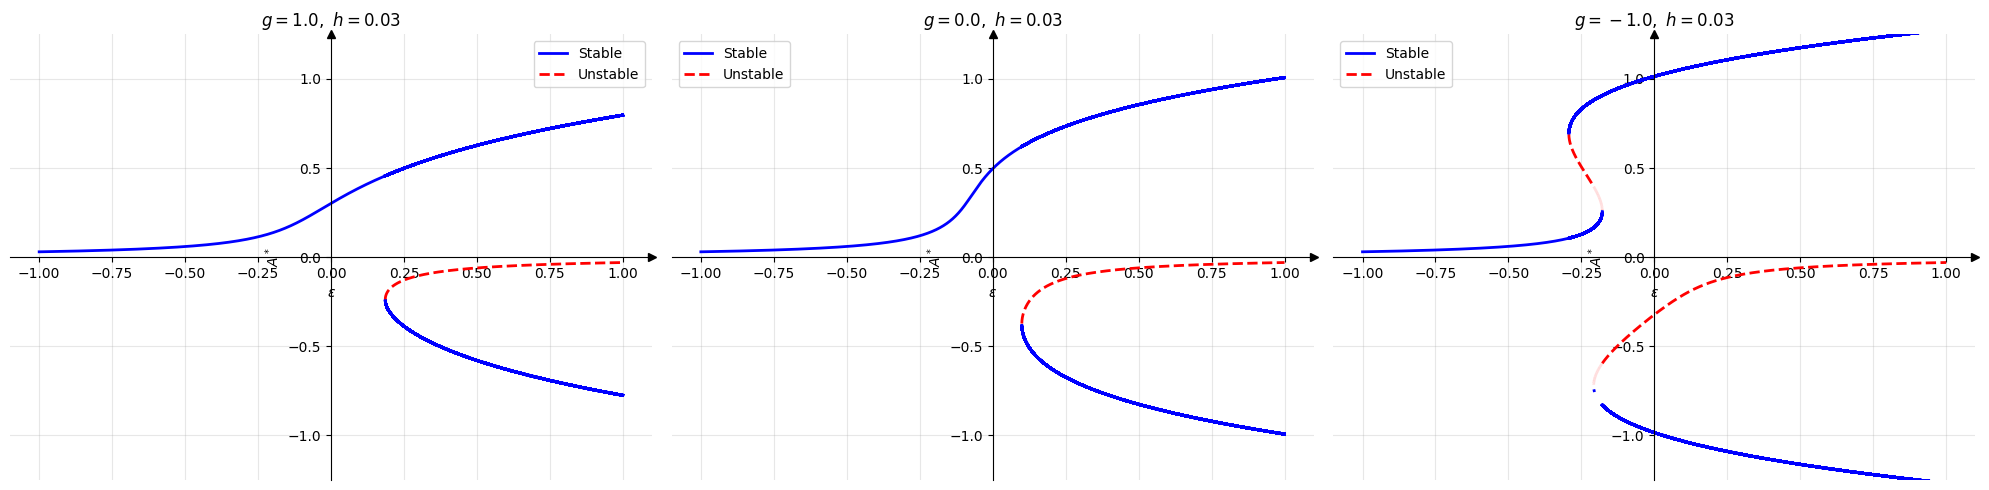

In [20]:
k = 1
h = 0.03
epsvals = np.linspace(-1,1,100000)
g_values = [1.0, 0.0, -1.0]
fig, ax = plt.subplots(1,3,figsize=(20,5))
for i,g in enumerate(g_values):
    E_st, A_st = [], []
    E_un, A_un = [], []
    for eps in epsvals:
        roots = np.roots([-k,0,-g,0,eps,h])
        for z in roots:
            if abs(z.imag) < 1e-8:
                A = z.real
                lam = eps - 3*g*A**2 - 5*k*A**4
                if lam < 0:
                    E_st.append(eps)
                    A_st.append(A)
                else:
                    E_un.append(eps)
                    A_un.append(A)

    ax1 = ax[i]
    idx = np.argsort(E_st)  #  Stable branches  
    E = np.array(E_st)[idx]
    A = np.array(A_st)[idx]
    Eplot = [E[0]]
    Aplot = [A[0]]
    for j in range(1,len(E)):
        if abs(A[j]-A[j-1]) > 0.01:   # break branch
            Eplot.append(np.nan)
            Aplot.append(np.nan)
        Eplot.append(E[j])
        Aplot.append(A[j])
    ax1.plot(Eplot,Aplot,'-b',lw=2,label='Stable')

    idx = np.argsort(E_un)     #  Unstable branches 
    E = np.array(E_un)[idx]
    A = np.array(A_un)[idx]
    Eplot = [E[0]]
    Aplot = [A[0]]
    for j in range(1,len(E)):
        if abs(A[j]-A[j-1]) > 0.01:
            Eplot.append(np.nan)
            Aplot.append(np.nan)
        Eplot.append(E[j])
        Aplot.append(A[j])
    ax1.plot(Eplot,Aplot,'--r',lw=2,label='Unstable')
    ax1.set_xlabel(r'$\varepsilon$')
    ax1.set_ylabel(r'$A^*$')
    ax1.set_title(fr'$g={g},\ h={h}$')
    ax1.set_ylim(-1.25,1.25)
    ax1.grid(alpha=0.3)
    ax1.legend()
    customize_axes(ax1)
plt.tight_layout()
plt.show()

**(d) Explanation of the transient plateaus**                                                                                                                    
After the quench at $t = 0$,                                                                                                                                      
$\qquad \qquad\displaystyle \tau \dot A = h + \varepsilon_f A + \vert{}g\vert{}A^3 - kA^5 \equiv F(A).$                                                                                               
The dynamics satisfy                                                                                                                                                  
$\qquad \qquad\displaystyle \dot A = \frac{1}{\tau} F(A).$

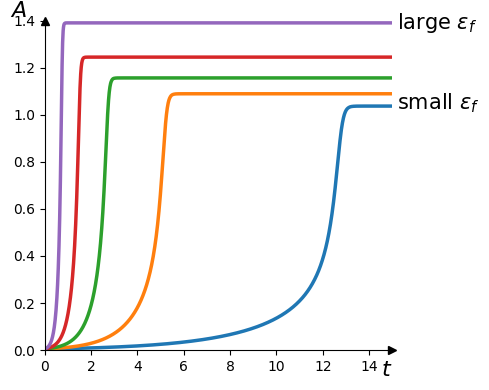

In [21]:
g = -1.0       # Negative g for explosive subcritical growth
k = 1.0        # Positive k to clamp the upper limits
h = 0.00        # Set to 0 to let the initial slopes depend purely on epsilon_f
tau = 0.25     # Faster timescale for crisp, sharp vertical turns

def f(t, A, eps_f):
    return (eps_f * A - g * A**3 - k * A**5) / tau

eps_f_values = [0.08, 0.22, 0.45, 0.85, 1.8]
t_span = (0, 20)
t_eval = np.linspace(0, 15, 2000)
A0 = [0.0050]  

fig, ax = plt.subplots(figsize=(5,4))

for eps_f in eps_f_values:
    sol = sc.integrate.solve_ivp(f, t_span, A0, args=(eps_f,), t_eval=t_eval, method='Radau')
    ax.plot(sol.t, sol.y[0], linewidth=2.5)

ax.set_xlim(0, 15)
ax.set_ylim(0, 1.4)
customize_axes(ax)
ax.set_xlabel('$t$', fontsize=16, loc='right', labelpad=-10)
ax.set_ylabel('$A$', fontsize=16, rotation=0, loc='top', labelpad=-10)
ax.text(15.2, 1.39, 'large $\\varepsilon_f$', fontsize=15, va='center')
ax.text(15.2, 1.05, 'small $\\varepsilon_f$', fontsize=15, va='center')
plt.tight_layout()
plt.show()

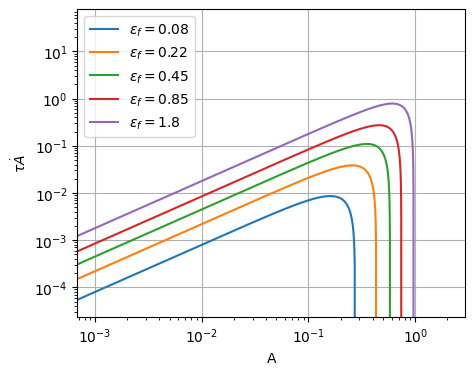

In [22]:
A = np.linspace(-2,2,2000)

plt.figure(figsize=(5,4))
 
for eps_f in eps_f_values:
    Adot = h + eps_f*A + g*A**3 - k*A**5
    plt.loglog(A,Adot,label=rf'$\epsilon_f={eps_f}$')

plt.axhline(0,color='k',ls='--')
plt.xlabel('A')
plt.ylabel(r'$\tau \dot A$')
plt.legend()
plt.grid(True)
plt.show()

**3.6.7**  <span style="color:red">(Simple model of a magnet)                                                                                                                              
A magnet can be modeled as an enormous collection of electronic spins.                                                                                      
In the simplest model, known as the Ising model, the spins can point only up or down, and are assigned the values $S_i = \pm 1,$ for $i = 1,\dots, N\gg 1$.          
For quantum mechanical reasons, the spins like to point in the same direction as their neighbors ;                                                          
on the other hand, the randomizing effects of temperature tend to disrupt any such alignment.                                                                                                               
An important macroscopic property of the magnet is its average spin or magnetization                                                                           
$\qquad\displaystyle m= \Bigg| \frac1{N}\sum_{i=1}^N S_i \Bigg|$                                                                                          
At high temperature the spins point in random directions and so $m \approx 0$; the material is in the paramagnetic state.                                             
As the temperature is lowered, $m$ remains near zero until a critical temperature $T_c$ is reached.                                                               
Then a phase transition occurs and the material spontaneously magnetizes. Now $m > 0$ ; we have a ferromagnet.                                                   
But the symmetry between up and down spins means that there are two possible ferromagnetic states.                                                            
This symmetry can be broken by applying an external magnetic field $h$, which favors either the up or down direction.                                             
Then, in an approximation called mean-field theory, the equation governing the equilibrium value of $m$ is                                                 
$\qquad\displaystyle h = T \tanh^{-1} m - Jnm $                                                                                                                                        
where $J$ and $n$ are constants $; \; \; J > 0$ is the ferromagnetic coupling strength and $n$ is the number of neighbors of each spin (Ma 1985, p. 459).                      
a) Analyze the solutions $m^{*}$ of $\displaystyle h = T \tanh^{-1} m - Jnm$ , using a graphical approach.                                                                              
b) For the special case $h = 0,$ find the critical temperature $T_c$ at which a phase transition occurs.<span>


**(a)**
Starting from                                                                                                                                             
$\qquad\displaystyle h = T\tanh^{-1}m - Jnm,$                                                                                                                                       
divide by $T$                                                                                                                                             
$\qquad\displaystyle \frac{h}{T} = \tanh^{-1}m - \frac{Jn}{T}m.$                                                                                                                                       
Rearrange:                                                                                                                                               
$\qquad\displaystyle \tanh^{-1}m = \frac{h}{T} + \frac{Jn}{T}m.$                                                                                                                                       
Therefore, in the form                                                                                                                                       
$\qquad\displaystyle \alpha + \beta m = \tanh^{-1}m,$                                                                                                                                       
we identify                                                                                                                                                 
$\qquad\displaystyle \alpha = \frac{h}{T}, \qquad \beta = \frac{Jn}{T}.$                                                                                                                                       
So the equilibrium equation becomes                                                                                                                                       
$\qquad\displaystyle \tanh^{-1}m = \alpha + \beta m.$                                                                                                                                       
The intersections give the equilibrium magnetizations ($m^*$).                                                                                                                                       
    

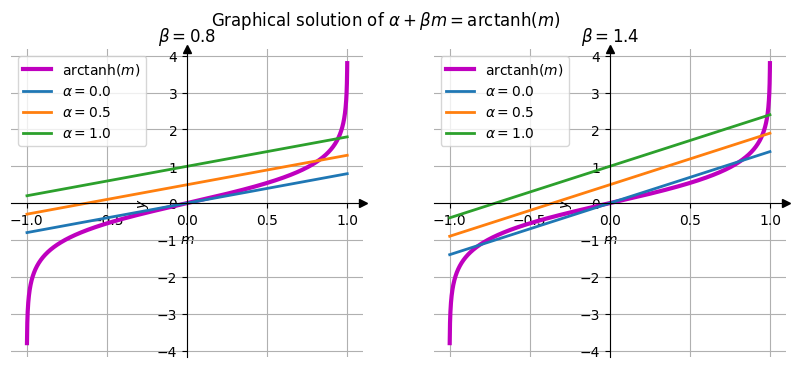

In [23]:
m = np.linspace(-0.999, 0.999, 4000)
y = np.arctanh(m)
beta = [0.8, 1.4]       
alphas = [0.0, 0.5, 1.0]

fig,ax=plt.subplots(1,2,figsize=(10,4))
for i,b in enumerate(beta):
    ax[i].plot(m, np.arctanh(m), 'm', lw=3,label=r'$\operatorname{arctanh}(m)$')
    for alpha in alphas:
        ax[i].plot(m,alpha + b*m,lw=2,label=rf'$\alpha={alpha}$')
    ax[i].set_xlabel(r'$m$')
    ax[i].set_ylabel(r'$y$')
    ax[i].grid(True)
    ax[i].set_title(rf'$\beta={b}$')
    ax[i].legend()
    customize_axes(ax[i])
fig.suptitle(r'Graphical solution of $\alpha+\beta m=\operatorname{arctanh}(m)$')

plt.show()

**(b)** When $h = 0$,                                                                                                                                            
$\qquad\qquad\displaystyle \alpha = 0,$                                                                                                                                            
so the straight line passes through the origin:                                                                                                                                            
$\qquad\displaystyle \tanh^{-1}m = \beta m.$                                                                                                                                            
Near $m = 0$,                                                                                                                                            
$\qquad\displaystyle \tanh^{-1}m = m + \frac{1}{3}m^3 + \cdots,$                                                                                                                                            
so the slope of the curve at the origin is                                                                                                                                            
$\qquad\displaystyle \left.\frac{d}{dm}\tanh^{-1}m\right|_{m=0} = 1.$                                                                                                                                            
The phase transition occurs when the line is tangent to the curve at the origin, i.e. when the slopes are equal:                                                                                                                                            
$\qquad\displaystyle \beta = 1.$                                                                                                                                             
Since                                                                                                                                                     
$\qquad\displaystyle \beta = \frac{Jn}{T},$                                                                                                                                            
we obtain                                                                                                                                                
$\qquad\displaystyle \frac{Jn}{T_c} = 1,$                                                                                                                                             
hence                                                                                                                                                    
$\qquad\boxed {\displaystyle T_c = Jn }$